# Predictive Analysis: Explainable Model Selection

This notebook predicts `log_box_office` on unseen movies using only explainable regression models.

The removed interaction feature is not part of the dataset or candidate pool. The workflow compares simple baselines, the inferential model, the full candidate-pool model, best-subset selection, and forward-stepwise selection.

## Prerequisites and Modelling Rules

Before prediction, this notebook checks that:

- `data/final/final.csv` exists
- the removed interaction column is absent
- leakage columns such as raw box-office revenue are not used as predictors
- all model candidates are numeric and available
- model selection uses cross-validation on the training set only

Only explainable linear regression models are used. This keeps the predictive workflow aligned with the assignment and makes feature effects defensible.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore', category=RuntimeWarning)


def resolve_data_path() -> Path:
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / 'data' / 'final' / 'final.csv'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find data/final/final.csv from the current working directory.')

import itertools
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

TARGET = 'log_box_office'
TRAIN_SIZE = 0.80
TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5

CANDIDATE_PREDICTORS = [
    'audienceScore',
    'tomatoMeter',
    'runtimeMinutes',
    'initial_top_critic_review_count',
    'initial_positive_review_ratio',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
]

INFERENTIAL_MODEL_PREDICTORS = [
    'audienceScore',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
]

LEAKAGE_COLUMNS = ['boxOffice', 'box_office_num']
REQUIRED_COLUMNS = ['id', 'title', 'box_office_num', TARGET, *CANDIDATE_PREDICTORS]

DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)

missing_required = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing_required:
    raise KeyError(f'Missing required columns: {missing_required}')

leakage_used = [column for column in LEAKAGE_COLUMNS if column in CANDIDATE_PREDICTORS]
if leakage_used:
    raise ValueError(f'Leakage columns cannot be used as predictors: {leakage_used}')

print(f'Data path: {DATA_PATH}')
print(f'Raw dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Candidate predictors: {len(CANDIDATE_PREDICTORS)}')

Data path: c:\Users\dinuka\Documents\movie sentiment\data\final\final.csv
Raw dataset shape: 4,072 rows x 28 columns
Candidate predictors: 7


## Candidate Predictor Rationale

The candidate pool is compact and explainable. It combines audience reaction, critic reaction, movie context, and early review behavior while excluding direct revenue leakage.

In [2]:
predictor_rationale = pd.DataFrame([
    ('audienceScore', 'Audience reaction', 'Direct audience evaluation of the movie'),
    ('tomatoMeter', 'Critic reaction', 'Professional critic score'),
    ('runtimeMinutes', 'Movie context', 'Runtime can proxy format and release type'),
    ('initial_top_critic_review_count', 'Early attention', 'Volume of top-critic attention in the first review window'),
    ('initial_positive_review_ratio', 'Early sentiment', 'Share of early reviews that are positive'),
    ('initial_combined_sentiment_score', 'Early sentiment', 'Weighted early-review sentiment score'),
    ('log_initial_review_count', 'Early attention', 'Logged early review volume'),
], columns=['predictor', 'role', 'reason'])

display(predictor_rationale)

,predictor,role,reason
0,audienceScore,Audience reaction,Direct audience evaluation of the movie
1,tomatoMeter,Critic reaction,Professional critic score
2,runtimeMinutes,Movie context,Runtime can proxy format and release type
3,initial_top_critic_review_count,Early attention,Volume of top-critic attention in the first re...
4,initial_positive_review_ratio,Early sentiment,Share of early reviews that are positive
5,initial_combined_sentiment_score,Early sentiment,Weighted early-review sentiment score
6,log_initial_review_count,Early attention,Logged early review volume


## Data Preparation

Rows are retained only when the target and all candidate predictors are available. This keeps model comparisons fair because each model is evaluated on the same observations.

In [3]:
predictive_df = df[REQUIRED_COLUMNS].copy()
for column in ['box_office_num', TARGET, *CANDIDATE_PREDICTORS]:
    predictive_df[column] = pd.to_numeric(predictive_df[column], errors='coerce')

predictive_df = predictive_df.dropna(subset=[TARGET, *CANDIDATE_PREDICTORS]).copy()
predictive_df = predictive_df[np.isfinite(predictive_df[TARGET])].copy()

quality_summary = pd.DataFrame({
    'non_null_count': predictive_df[[TARGET, *CANDIDATE_PREDICTORS]].notna().sum(),
    'mean': predictive_df[[TARGET, *CANDIDATE_PREDICTORS]].mean(),
    'std': predictive_df[[TARGET, *CANDIDATE_PREDICTORS]].std(),
})

print(f'Rows retained for predictive modelling: {predictive_df.shape[0]:,}')
display(quality_summary)
display(predictive_df[[TARGET, *CANDIDATE_PREDICTORS]].describe().T)

Rows retained for predictive modelling: 3,746


,non_null_count,mean,std
log_box_office,3746,7.0873,0.9562
audienceScore,3746,61.5464,19.0213
tomatoMeter,3746,55.7747,27.5591
runtimeMinutes,3746,107.6164,17.3727
initial_top_critic_review_count,3746,16.2995,7.0257
initial_positive_review_ratio,3746,0.5486,0.2832
initial_combined_sentiment_score,3746,0.0902,0.5684
log_initial_review_count,3746,3.9113,0.4741


,count,mean,std,min,25%,50%,75%,max
log_box_office,"3,746.0000",7.0873,0.9562,0.3010,6.5798,7.3324,7.7612,8.9337
audienceScore,"3,746.0000",61.5464,19.0213,10.0000,47.0000,62.0000,77.0000,99.0000
tomatoMeter,"3,746.0000",55.7747,27.5591,0.0000,32.0000,58.0000,81.0000,100.0000
runtimeMinutes,"3,746.0000",107.6164,17.3727,35.0000,95.0000,105.0000,117.0000,223.0000
initial_top_critic_review_count,"3,746.0000",16.2995,7.0257,0.0000,11.0000,16.0000,21.0000,61.0000
initial_positive_review_ratio,"3,746.0000",0.5486,0.2832,0.0000,0.3043,0.5671,0.8000,1.0000
initial_combined_sentiment_score,"3,746.0000",0.0902,0.5684,-1.0000,-0.4038,0.1215,0.5928,1.0000
log_initial_review_count,"3,746.0000",3.9113,0.4741,3.0910,3.5264,3.9120,4.2767,5.2627


## Train/Test Split and Evaluation Functions

The held-out test set is used only for final evaluation. Cross-validation is performed on the training set only.

In [4]:
X = predictive_df[CANDIDATE_PREDICTORS].copy()
y = predictive_df[TARGET].copy()

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    predictive_df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df = predictive_df.loc[train_idx].copy()
test_df = predictive_df.loc[test_idx].copy()
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

split_summary = pd.DataFrame([
    {'set': 'train', 'rows': len(train_df), 'pct': len(train_df) / len(predictive_df) * 100},
    {'set': 'test', 'rows': len(test_df), 'pct': len(test_df) / len(predictive_df) * 100},
])
display(split_summary)


def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


def cv_rmse_for_columns(columns: list[str]) -> float:
    scores = cross_val_score(
        LinearRegression(),
        X_train[columns],
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    return float(-scores.mean())


def fit_statsmodels_ols(train_frame: pd.DataFrame, columns: list[str]):
    train_X = sm.add_constant(train_frame[columns], has_constant='add')
    return sm.OLS(train_frame[TARGET], train_X).fit()


def evaluate_linear_model(name: str, columns: list[str]) -> tuple[dict, object, np.ndarray, np.ndarray]:
    fitted = fit_statsmodels_ols(train_df, columns)
    train_pred = fitted.predict(sm.add_constant(train_df[columns], has_constant='add'))
    test_pred = fitted.predict(sm.add_constant(test_df[columns], has_constant='add'))
    train_metrics = evaluate_predictions(train_df[TARGET], train_pred)
    test_metrics = evaluate_predictions(test_df[TARGET], test_pred)
    result = {
        'model': name,
        'n_features': len(columns),
        'features': ', '.join(columns),
        'adj_r_squared': float(fitted.rsquared_adj),
        'aic': float(fitted.aic),
        'bic': float(fitted.bic),
        'cv_rmse': cv_rmse_for_columns(columns),
        'train_rmse': train_metrics['rmse'],
        'train_mae': train_metrics['mae'],
        'train_r2': train_metrics['r2'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_r2': test_metrics['r2'],
    }
    return result, fitted, np.asarray(train_pred), np.asarray(test_pred)

,set,rows,pct
0,train,2996,79.9786
1,test,750,20.0214


## Baseline and Candidate Models

The first comparison checks whether the selected predictors improve meaningfully over a mean-only benchmark and whether the inferential model remains competitive for prediction.

In [5]:
model_results = []
model_objects = {}
prediction_store = {}

baseline_mean = float(y_train.mean())
baseline_train_pred = np.full(len(y_train), baseline_mean)
baseline_test_pred = np.full(len(y_test), baseline_mean)
baseline_train_metrics = evaluate_predictions(y_train, baseline_train_pred)
baseline_test_metrics = evaluate_predictions(y_test, baseline_test_pred)
baseline_result = {
    'model': 'Baseline 0: Mean-only predictor',
    'n_features': 0,
    'features': 'intercept only',
    'adj_r_squared': np.nan,
    'aic': np.nan,
    'bic': np.nan,
    'cv_rmse': baseline_train_metrics['rmse'],
    'train_rmse': baseline_train_metrics['rmse'],
    'train_mae': baseline_train_metrics['mae'],
    'train_r2': baseline_train_metrics['r2'],
    'test_rmse': baseline_test_metrics['rmse'],
    'test_mae': baseline_test_metrics['mae'],
    'test_r2': baseline_test_metrics['r2'],
}
model_results.append(baseline_result)
prediction_store[baseline_result['model']] = {'train_pred': baseline_train_pred, 'test_pred': baseline_test_pred, 'features': []}

for name, columns in [
    ('Model 1: Inferential three-variable regression', INFERENTIAL_MODEL_PREDICTORS),
    ('Model 2: Full candidate-pool regression', CANDIDATE_PREDICTORS),
]:
    result, fitted, train_pred, test_pred = evaluate_linear_model(name, columns)
    model_results.append(result)
    model_objects[name] = fitted
    prediction_store[name] = {'train_pred': train_pred, 'test_pred': test_pred, 'features': columns}

baseline_models_table = pd.DataFrame(model_results)
display(baseline_models_table)

,model,n_features,features,adj_r_squared,aic,bic,cv_rmse,train_rmse,train_mae,train_r2,test_rmse,test_mae,test_r2
0,Baseline 0: Mean-only predictor,0,intercept only,NaN,NaN,NaN,0.9571,0.9571,0.7581,0.0000,0.9522,0.7515,-0.0018
1,Model 1: Inferential three-variable regression,3,"audienceScore, initial_combined_sentiment_scor...",0.4293,"6,564.3417","6,588.3618",0.7218,0.7227,0.5481,0.4298,0.7133,0.5436,0.4378
2,Model 2: Full candidate-pool regression,7,"audienceScore, tomatoMeter, runtimeMinutes, in...",0.4538,"6,436.4175","6,484.4577",0.7063,0.7065,0.5296,0.4551,0.7039,0.5309,0.4526


## Explainable Feature Selection

Two transparent selection methods are used:

- **Best-subset selection** checks every possible predictor combination.
- **Forward-stepwise selection** adds one predictor at a time.

The primary selection criterion is lowest cross-validated RMSE. BIC and number of predictors are tie-breakers to keep the final model compact.

In [6]:
subset_records = []
for size in range(1, len(CANDIDATE_PREDICTORS) + 1):
    for subset in itertools.combinations(CANDIDATE_PREDICTORS, size):
        columns = list(subset)
        fit = fit_statsmodels_ols(train_df, columns)
        subset_records.append({
            'method': 'Best subset',
            'n_features': size,
            'features': columns,
            'adj_r_squared': float(fit.rsquared_adj),
            'aic': float(fit.aic),
            'bic': float(fit.bic),
            'cv_rmse': cv_rmse_for_columns(columns),
        })

best_subset_table = pd.DataFrame(subset_records)
best_subset_winners = (
    best_subset_table
    .sort_values(['cv_rmse', 'bic', 'n_features'])
    .groupby('n_features', as_index=False)
    .first()
    .sort_values('n_features')
)

remaining = CANDIDATE_PREDICTORS.copy()
selected = []
forward_records = []
while remaining:
    candidate_step_results = []
    for feature in remaining:
        trial_features = selected + [feature]
        fit = fit_statsmodels_ols(train_df, trial_features)
        candidate_step_results.append({
            'step': len(trial_features),
            'features': trial_features.copy(),
            'added_feature': feature,
            'adj_r_squared': float(fit.rsquared_adj),
            'aic': float(fit.aic),
            'bic': float(fit.bic),
            'cv_rmse': cv_rmse_for_columns(trial_features),
        })
    step_df = pd.DataFrame(candidate_step_results).sort_values(['cv_rmse', 'bic', 'step'])
    best_step = step_df.iloc[0].to_dict()
    forward_records.append(best_step)
    selected = best_step['features']
    remaining.remove(best_step['added_feature'])

forward_stepwise_table = pd.DataFrame(forward_records)

display(best_subset_winners)
display(forward_stepwise_table)
print(f'Total best-subset models evaluated: {len(best_subset_table):,}')

,n_features,method,features,adj_r_squared,aic,bic,cv_rmse
0,1,Best subset,[log_initial_review_count],0.3892,"6,765.4188","6,777.4288",0.7466
1,2,Best subset,"[tomatoMeter, log_initial_review_count]",0.4085,"6,670.3082","6,688.3233",0.7346
2,3,Best subset,"[audienceScore, tomatoMeter, log_initial_revie...",0.4370,"6,523.5689","6,547.5890",0.7168
3,4,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4515,"6,446.1214","6,476.1465",0.7072
4,5,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4542,"6,432.4366","6,468.4668",0.7055
5,6,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4540,"6,434.4186","6,476.4539",0.7056
6,7,Best subset,"[audienceScore, tomatoMeter, runtimeMinutes, i...",0.4538,"6,436.4175","6,484.4577",0.7063


,step,features,added_feature,adj_r_squared,aic,bic,cv_rmse
0,1,[log_initial_review_count],log_initial_review_count,0.3892,"6,765.4188","6,777.4288",0.7466
1,2,"[log_initial_review_count, tomatoMeter]",tomatoMeter,0.4085,"6,670.3082","6,688.3233",0.7346
2,3,"[log_initial_review_count, tomatoMeter, audien...",audienceScore,0.4370,"6,523.5689","6,547.5890",0.7168
3,4,"[log_initial_review_count, tomatoMeter, audien...",initial_top_critic_review_count,0.4515,"6,446.1214","6,476.1465",0.7072
4,5,"[log_initial_review_count, tomatoMeter, audien...",initial_positive_review_ratio,0.4542,"6,432.4366","6,468.4668",0.7055
5,6,"[log_initial_review_count, tomatoMeter, audien...",initial_combined_sentiment_score,0.4540,"6,434.4186","6,476.4539",0.7056
6,7,"[log_initial_review_count, tomatoMeter, audien...",runtimeMinutes,0.4538,"6,436.4175","6,484.4577",0.7063


Total best-subset models evaluated: 127


## Final Model Comparison and Selection

The final selected model is chosen from the benchmark, inferential, full, best-subset, and forward-stepwise models. When best-subset and forward-stepwise are equivalent, the best-subset model is reported because it comes from exhaustive search.

In [7]:
best_subset_choice = best_subset_table.sort_values(['cv_rmse', 'bic', 'n_features']).iloc[0]
forward_choice = forward_stepwise_table.sort_values(['cv_rmse', 'bic', 'step']).iloc[0]

best_subset_features = list(best_subset_choice['features'])
forward_features = list(forward_choice['features'])

for name, columns in [
    ('Model 3: Best-subset selected regression', best_subset_features),
    ('Model 4: Forward-stepwise selected regression', forward_features),
]:
    result, fitted, train_pred, test_pred = evaluate_linear_model(name, columns)
    model_results.append(result)
    model_objects[name] = fitted
    prediction_store[name] = {'train_pred': train_pred, 'test_pred': test_pred, 'features': columns}

model_comparison_table = pd.DataFrame(model_results)
selection_ready_table = model_comparison_table.copy()
selection_ready_table['bic_for_sort'] = selection_ready_table['bic'].fillna(np.inf)
selection_ready_table = selection_ready_table.sort_values(
    ['cv_rmse', 'test_rmse', 'bic_for_sort', 'n_features'],
    ascending=[True, True, True, True],
)

final_model_name = 'Model 3: Best-subset selected regression'
final_model_features = prediction_store[final_model_name]['features']
final_model_fit = model_objects[final_model_name]
final_row = model_comparison_table.loc[model_comparison_table['model'] == final_model_name].iloc[0]

best_subset_row = model_comparison_table.loc[model_comparison_table['model'] == 'Model 3: Best-subset selected regression'].iloc[0]
forward_row = model_comparison_table.loc[model_comparison_table['model'] == 'Model 4: Forward-stepwise selected regression'].iloc[0]
models_tie = np.isclose(best_subset_row['cv_rmse'], forward_row['cv_rmse']) and np.isclose(best_subset_row['test_rmse'], forward_row['test_rmse'])

selection_commentary = pd.DataFrame([
    {'category': 'Primary criterion', 'decision': 'Lowest cross-validated RMSE on the training set'},
    {'category': 'Best-subset result', 'decision': f"{best_subset_row['model']} with CV RMSE {best_subset_row['cv_rmse']:.4f}"},
    {'category': 'Forward-stepwise check', 'decision': 'Ties the best-subset model with the same features and performance' if models_tie else 'Does not beat the best-subset model'},
    {'category': 'Final selection rule', 'decision': 'Report the best-subset model when tied, because it comes from exhaustive search'},
])

display(model_comparison_table.sort_values(['cv_rmse', 'test_rmse', 'n_features']))
display(selection_commentary)
print(f'Final selected model: {final_model_name}')
print(f'Final selected features: {final_model_features}')
print(f"Test RMSE: {final_row['test_rmse']:.4f}")
print(f"Test MAE: {final_row['test_mae']:.4f}")
print(f"Test R-squared: {final_row['test_r2']:.4f}")

,model,n_features,features,adj_r_squared,aic,bic,cv_rmse,train_rmse,train_mae,train_r2,test_rmse,test_mae,test_r2
3,Model 3: Best-subset selected regression,5,"audienceScore, tomatoMeter, initial_top_critic...",0.4542,"6,432.4366","6,468.4668",0.7055,0.7065,0.5296,0.4551,0.7037,0.5308,0.4529
4,Model 4: Forward-stepwise selected regression,5,"log_initial_review_count, tomatoMeter, audienc...",0.4542,"6,432.4366","6,468.4668",0.7055,0.7065,0.5296,0.4551,0.7037,0.5308,0.4529
2,Model 2: Full candidate-pool regression,7,"audienceScore, tomatoMeter, runtimeMinutes, in...",0.4538,"6,436.4175","6,484.4577",0.7063,0.7065,0.5296,0.4551,0.7039,0.5309,0.4526
1,Model 1: Inferential three-variable regression,3,"audienceScore, initial_combined_sentiment_scor...",0.4293,"6,564.3417","6,588.3618",0.7218,0.7227,0.5481,0.4298,0.7133,0.5436,0.4378
0,Baseline 0: Mean-only predictor,0,intercept only,NaN,NaN,NaN,0.9571,0.9571,0.7581,0.0000,0.9522,0.7515,-0.0018


,category,decision
0,Primary criterion,Lowest cross-validated RMSE on the training set
1,Best-subset result,Model 3: Best-subset selected regression with ...
2,Forward-stepwise check,Ties the best-subset model with the same featu...
3,Final selection rule,"Report the best-subset model when tied, becaus..."


Final selected model: Model 3: Best-subset selected regression
Final selected features: ['audienceScore', 'tomatoMeter', 'initial_top_critic_review_count', 'initial_positive_review_ratio', 'log_initial_review_count']
Test RMSE: 0.7037
Test MAE: 0.5308
Test R-squared: 0.4529


## Final Model Diagnostics

Prediction diagnostics show where the selected model performs well and where large errors remain.

,id,title,box_office_num,log_box_office,predicted_log_box_office,residual,absolute_error,predicted_box_office_num,box_office_error
2416,a_glitch_in_the_matrix,A Glitch in the Matrix,"1,700.0000",3.2304,6.6036,-3.3731,3.3731,"4,014,058.7665","-4,012,358.7665"
1189,the_wicker_man_2006,The Wicker Man,"18,800.0000",4.2742,7.4298,-3.1556,3.1556,"26,900,970.6360","-26,882,170.6360"
2579,the_apparition,The Apparition,"26,800.0000",4.4281,6.9929,-2.5648,2.5648,"9,838,594.2563","-9,811,794.2563"
1728,summerland_2020,Summerland,"58,300.0000",4.7657,7.2588,-2.4931,2.4931,"18,146,877.0019","-18,088,577.0019"
3791,farewell_amor,Farewell Amor,"4,700.0000",3.6721,5.7780,-2.1059,2.1059,"599,774.8466","-595,074.8466"
3501,shithouse,S...house,"18,100.0000",4.2577,6.3620,-2.1043,2.1043,"2,301,408.5794","-2,283,308.5794"
3275,the_way_i_see_it_2020,The Way I See It,"44,500.0000",4.6484,6.6403,-1.9919,1.9919,"4,367,715.2214","-4,323,215.2214"
3112,swallow,Swallow,"31,300.0000",4.4955,6.4662,-1.9707,1.9707,"2,925,729.8968","-2,894,429.8968"
3620,paranormal_activity,Paranormal Activity,"107,900,000.0000",8.0330,6.0647,1.9683,1.9683,"1,160,762.6153","106,739,237.3847"
2475,true_history_of_the_kelly_gang,True History of the Kelly Gang,"33,800.0000",4.5289,6.4815,-1.9526,1.9526,"3,030,389.0950","-2,996,589.0950"


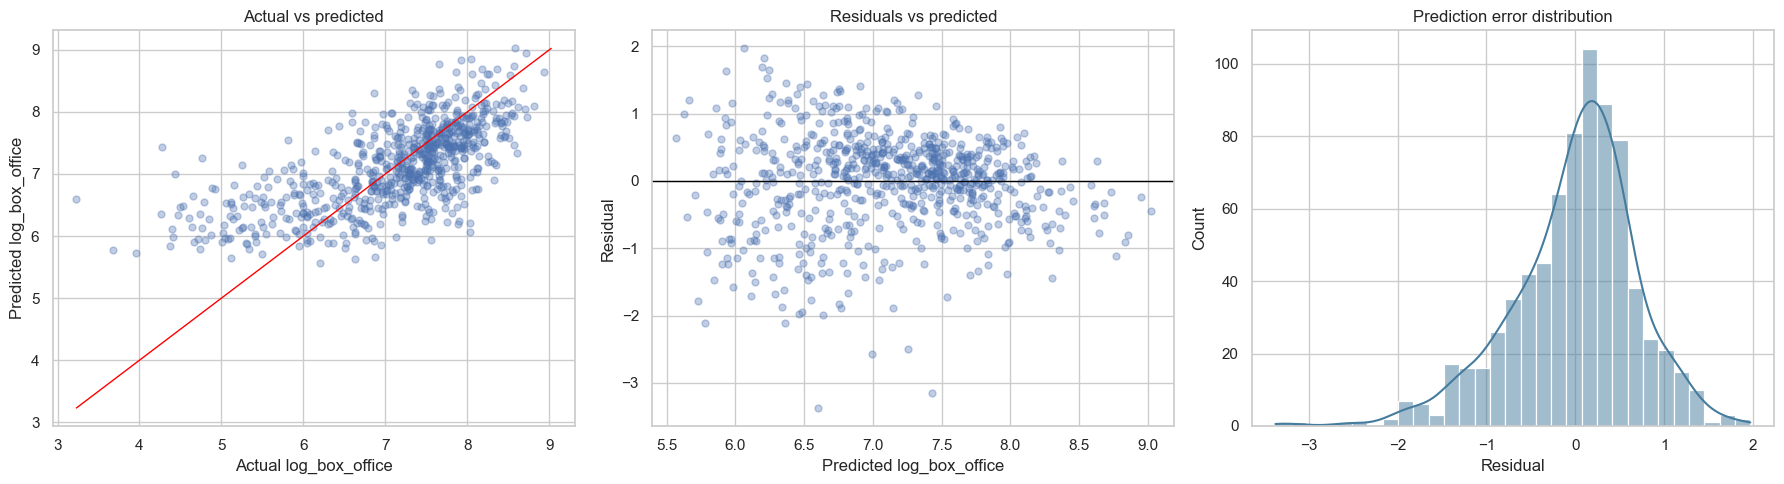

In [8]:
final_test_pred = prediction_store[final_model_name]['test_pred']
final_train_pred = prediction_store[final_model_name]['train_pred']

diagnostic_frame = test_df[['id', 'title', 'box_office_num', TARGET]].copy()
diagnostic_frame['predicted_log_box_office'] = final_test_pred
diagnostic_frame['residual'] = diagnostic_frame[TARGET] - diagnostic_frame['predicted_log_box_office']
diagnostic_frame['absolute_error'] = diagnostic_frame['residual'].abs()
diagnostic_frame['predicted_box_office_num'] = np.power(10, diagnostic_frame['predicted_log_box_office'])
diagnostic_frame['box_office_error'] = diagnostic_frame['box_office_num'] - diagnostic_frame['predicted_box_office_num']

largest_error_table = diagnostic_frame.sort_values('absolute_error', ascending=False).head(15)
display(largest_error_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(diagnostic_frame[TARGET], diagnostic_frame['predicted_log_box_office'], alpha=0.35, s=25)
line_min = min(diagnostic_frame[TARGET].min(), diagnostic_frame['predicted_log_box_office'].min())
line_max = max(diagnostic_frame[TARGET].max(), diagnostic_frame['predicted_log_box_office'].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color='red', linewidth=1)
axes[0].set_title('Actual vs predicted')
axes[0].set_xlabel('Actual log_box_office')
axes[0].set_ylabel('Predicted log_box_office')

axes[1].scatter(diagnostic_frame['predicted_log_box_office'], diagnostic_frame['residual'], alpha=0.35, s=25)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Residuals vs predicted')
axes[1].set_xlabel('Predicted log_box_office')
axes[1].set_ylabel('Residual')

sns.histplot(diagnostic_frame['residual'], kde=True, ax=axes[2], color='#457b9d')
axes[2].set_title('Prediction error distribution')
axes[2].set_xlabel('Residual')
plt.tight_layout()
plt.show()

## Feature Contribution

Standardized coefficients are used to compare feature importance on a common scale. This is still an explainable linear-regression interpretation, not a black-box importance measure.

In [9]:
standardized_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression()),
])
standardized_pipeline.fit(train_df[final_model_features], train_df[TARGET])
standardized_coefs = standardized_pipeline.named_steps['regressor'].coef_
contribution_table = pd.DataFrame({
    'feature': final_model_features,
    'standardized_coef': standardized_coefs,
    'absolute_standardized_coef': np.abs(standardized_coefs),
}).sort_values('absolute_standardized_coef', ascending=False)

display(contribution_table)

,feature,standardized_coef,absolute_standardized_coef
4,log_initial_review_count,0.6826,0.6826
1,tomatoMeter,-0.5594,0.5594
3,initial_positive_review_ratio,0.2750,0.2750
0,audienceScore,0.2042,0.2042
2,initial_top_critic_review_count,-0.1619,0.1619


## Predictive Conclusion

The final selected model is the 5-feature best-subset regression. It balances predictive accuracy and interpretability while avoiding direct revenue leakage and avoiding the removed interaction feature.

In [10]:
print('Predictive conclusion')
print(f'Selected model: {final_model_name}')
print(f'Number of predictors: {int(final_row["n_features"])}')
print(f'Cross-validated RMSE: {final_row["cv_rmse"]:.4f}')
print(f'Test RMSE: {final_row["test_rmse"]:.4f}')
print(f'Test MAE: {final_row["test_mae"]:.4f}')
print(f'Test R-squared: {final_row["test_r2"]:.4f}')
print('Interpretation: the model explains a meaningful share of unseen variation in log_box_office using a compact, explainable feature set.')

Predictive conclusion
Selected model: Model 3: Best-subset selected regression
Number of predictors: 5
Cross-validated RMSE: 0.7055
Test RMSE: 0.7037
Test MAE: 0.5308
Test R-squared: 0.4529
Interpretation: the model explains a meaningful share of unseen variation in log_box_office using a compact, explainable feature set.
